# Oprec Ristek Data Science SIG

## Deskripsi data

In [ ]:
# Mendownload data dari drive
import gdown

meta_url = 'https://drive.google.com/uc?id='
url_1 = meta_url + '1F1uSWppX7FPXsk4rKkNcW6hSli2uqdu1'
url_2 = meta_url + '11jzHVXm_Da0fPSNqo5JvEpMHE8vQL3Yh'
url_3 = meta_url + '1Aw6NH6W0mnczUx5pnE8QgCuui-LI4DFI'

output_1 = 'test.csv'
output_2 = 'train.csv'
output_3 = 'submission.csv'

gdown.download(url_1, output_1, quiet=False)
gdown.download(url_2, output_2, quiet=False)
gdown.download(url_3, output_3, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1F1uSWppX7FPXsk4rKkNcW6hSli2uqdu1
To: /content/test.csv
Downloading...
From: https://drive.google.com/uc?id=11jzHVXm_Da0fPSNqo5JvEpMHE8vQL3Yh
To: /content/train.csv
Downloading...
From: https://drive.google.com/uc?id=1Aw6NH6W0mnczUx5pnE8QgCuui-LI4DFI
To: /content/submission.csv


'submission.csv'

In [ ]:
# Meng-import modul yang dibutuhkan
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Membaca train dataset
df = pd.read_csv('/content/train.csv')

In [ ]:
df.head() # Melihat sekilas dataset

id                  played_at  \
0  0205bd314da54b6fb363a998ca0c49ba  2022-02-25 03:01:50+00:00   
1  7ca6c874c8064364b4247780495fe4f2  2021-10-17 05:11:18+00:00   
2  92ccfb1330424a4fb572585b8d6ea4c9  2021-10-10 01:50:23+00:00   
3  d592c15de2a94b6aa5278b0fc241de54  2022-02-25 04:27:49+00:00   
4  6a24b0487aef460a982d2ec930947c11  2021-12-15 19:17:24+00:00   

               tournament                    map  game_length  winner matchup  \
0            IEM Katowice       2000 애트모스피어 - 래더          848       2     TvT   
1       DH Masters Winter  Beckett Industries LE          612       1     PvZ   
2       DH Masters Winter  Beckett Industries LE          486       2     PvZ   
3            IEM Katowice       [ESL] Berlingrad         1078       2     PvZ   
4  DH Masters Last Chance               블랙번 - 래더         1001       1     PvZ   

   p1_max_collection_rate  p2_max_collection_rate  p1_apm  ...  \
0                    3778                    3952     316  ...   
1                    4344                    3140     398  ...   
2                    3095                    2944     389  ...   
3                    4064                    4193     449  ...   
4                    4484                    4243     627  ...   

   p1_avg_collection_rate_gas  p1_avg_unspent_gas  p1_gas_lost  \
0                       533.8               273.8         3436   
1                       473.9               236.7          625   
2                       226.5               157.6          800   
3                       749.7               401.2         5850   
4                       826.1               299.8         8975   

   p1_gas_collected  p2_avg_collection_rate_gas  p2_avg_unspent_gas  \
0              6384                       636.3               253.2   
1              4265                       427.4               201.3   
2              1668                       336.1               170.0   
3             11682                       892.6               664.5   
4             11930                       675.6               174.5   

   p2_gas_lost  p2_gas_collected  p1_race  p2_race  
0         2864              7412   Terran   Terran  
1          850              3665     Zerg  Protoss  
2           75              2436     Zerg  Protoss  
3         3850             13344  Protoss     Zerg  
4         8200             10256     Zerg  Protoss  

[5 rows x 49 columns]

In [ ]:
train = df.copy() # Membuat salinan untuk training model

## Data Preprocessing dan Cleaning

In [ ]:
# Memeriksa apakah ada missing value
train.isnull().sum()

id                                 0
played_at                          0
tournament                         0
map                                0
game_length                        0
winner                             0
matchup                            0
p1_max_collection_rate             0
p2_max_collection_rate             0
p1_apm                             0
p2_apm                             0
p1_spm                             0
p2_spm                             0
p1_workers_produced                0
p2_workers_produced                0
p1_workers_killed                  0
p2_workers_killed                  0
p1_workers_lost                    0
p2_workers_lost                    0
p1_supply_block                    0
p2_supply_block                    0
p1_sq                              0
p2_sq                              0
p1_avg_pac_per_min                 0
p2_avg_pac_per_min                 0
p1_avg_pac_action_latency          0
p2_avg_pac_action_latency          0
p

In [ ]:
# Memeriksa data yang mempunyai tipe objek

train.select_dtypes(include='object').columns

Index(['id', 'played_at', 'tournament', 'map', 'matchup', 'p1_race',
       'p2_race'],
      dtype='object')

In [ ]:
# Melihat apa yang ada di column played_at
train['played_at'].value_counts()

2021-12-15 17:13:26+00:00    2
2022-02-23 19:11:35+00:00    1
2022-02-25 01:15:37+00:00    1
2021-10-06 01:17:27+00:00    1
2021-12-18 03:48:10+00:00    1
                            ..
2022-02-23 23:19:38+00:00    1
2022-02-24 19:33:55+00:00    1
2021-10-07 22:24:52+00:00    1
2021-12-20 08:22:13+00:00    1
2021-10-04 01:32:52+00:00    1
Name: played_at, Length: 828, dtype: int64

In [ ]:
# Melihat apa yang ada di column tournament
train['tournament'].value_counts()

DH Masters Winter         448
DH Masters Last Chance    224
IEM Katowice              157
Name: tournament, dtype: int64

In [ ]:
# Melihat apa yang ada di column map
train['map'].value_counts()

2000 Atmospheres LE          156
Jagannatha LE                 64
Blackburn LE                  62
Romanticide LE                60
Oxide LE                      59
Lightshade LE                 55
[ESL] Hardwire                32
2000 애트모스피어 - 래더              28
[ESL] Berlingrad              28
[TLMC15] Hardwire             21
Hardwire LE                   19
Curious Minds LE              18
[ESL] Blackburn               16
[ESL] Glittering Ashes        15
Glittering Ashes LE           15
Beckett Industries LE         14
[ESL] Curious Minds           14
[TLMC15] Berlingrad           14
하드와이어 - 래더                    13
[TLMC15] Glittering Ashes     12
베를린그라드 - 래더                   11
Berlingrad LE                 11
[TLMC14] Blackburn            11
글리터링 애쉬즈 - 래더                 10
[ESL] Pride of Altaris         8
큐리어스 마인즈 - 래더                  8
大气2000-天梯版                     7
블랙번 - 래더                       7
[TLMC15] Curious Minds         7
프라이드 오브 알타리스 - 래더              5
Pride of A

- column 'played_at' dirasa tidak membantu dalam prediksi race, maka akan di drop
- column 'tournament' dirasa tidak membantu dalam prediksi race, maka akan di drop
- column 'map' terlalu random wkwk

In [ ]:
train.drop(['played_at', 'tournament', 'id', 'matchup', 'map'], axis=1, inplace=True)

Cara yang akan saya gunakan untuk memprediksi matchup adalah dengan memprediksi race dari player 1 dan race dari player 2. Oleh karena itu, saya akan menyatukan data player 1 dengan data player 2 untuk training model. Sebelum disatukan, saya akan memisahkan data player 1 dan player 2 ke dataframe yang berbeda, lalu disatukan.

In [ ]:
# Membuat dataframe baru untuk player 1
datap1 = train.copy()
# Menghilangkan data player 2
for name in datap1.columns:
  if name[0:2] == 'p2':
    datap1.drop([name], axis=1, inplace=True)
# Mendapatkan status kemenangan player 1
new_winner = []
for win in datap1['winner']:
  if win == 2:
    new_winner.append(0)
  else:
    new_winner.append(1)
datap1['winner'] = new_winner
# Menyamakan column name dengan dataframe player 2
datap1.columns = datap1.columns.str.replace("p1_", "")

In [ ]:
# Membuat dataframe baru untuk player 2
datap2 = train.copy()
# Menghilangkan data player 1
for name in datap2.columns:
  if name[0:2] == 'p1':
    datap2.drop([name], axis=1, inplace=True)
# Mendapatkan status kemenangan player 2
new_winner = []
for win in datap2['winner']:
  if win == 2:
    new_winner.append(1)
  else:
    new_winner.append(0)
datap2['winner'] = new_winner
# Menyamakan column name dengan dataframe player 1
datap2.columns = datap2.columns.str.replace("p2_", "")

In [ ]:
# Membuat dataframe baru yang berupa gabungan dataframe player 1 dan player 2
newdf = pd.concat([datap1, datap2], axis=0)
newdf

game_length  winner  max_collection_rate  apm   spm  workers_produced  \
0            848       0                 3778  316  26.3                75   
1            612       1                 4344  398  42.9                97   
2            486       0                 3095  389  35.9                80   
3           1078       0                 4064  449  40.2                77   
4           1001       1                 4484  627  37.6                98   
..           ...     ...                  ...  ...   ...               ...   
824         1059       0                 3471  415  33.9                89   
825          473       0                 2625  410  16.5                49   
826          650       1                 3510  335  45.0                66   
827          881       0                 3862  379  45.5               100   
828          447       1                 2311  296  45.5                48   

     workers_killed  workers_lost  supply_block   sq  ...  avg_pac_gap  \
0                18            17            75  134  ...         0.06   
1                22            21            30  126  ...         0.06   
2                11            17            20  118  ...         0.06   
3                68            30            15  138  ...         0.06   
4                24            25            25  169  ...         0.04   
..              ...           ...           ...  ...  ...          ...   
824              54            51            45  121  ...         0.07   
825               3             4            20  119  ...         0.04   
826               7             3             5  138  ...         0.08   
827              30            37            40  123  ...         0.08   
828              18             6            50  111  ...         0.07   

     avg_collection_rate_minerals  avg_unspent_minerals  minerals_lost  \
0                          1808.2                 241.2          10341   
1                          1938.9                 473.6           3075   
2                          1563.7                 232.1           4200   
3                          2107.6                 535.6          13650   
4                          2306.8                 259.8          21675   
..                            ...                   ...            ...   
824                        1583.5                 341.4          12968   
825                        1246.9                 150.1           1725   
826                        1876.5                 268.4           8575   
827                        1622.3                 292.6           5535   
828                        1064.1                 122.5            475   

     minerals_collected  avg_collection_rate_gas  avg_unspent_gas  gas_lost  \
0                 25162                    533.8            273.8      3436   
1                 20305                    473.9            236.7       625   
2                 13525                    226.5            157.6       800   
3                 37470                    749.7            401.2      5850   
4                 37048                    826.1            299.8      8975   
..                  ...                      ...              ...       ...   
824               27055                    446.9            147.0      4018   
825               10705                    332.4            129.8       600   
826               21220                    457.3            195.0      1250   
827               24609                    580.9            295.9      2925   
828                8575                    269.3            128.7       225   

     gas_collected     race  
0             6384   Terran  
1             4265     Zerg  
2             1668     Zerg  
3            11682  Protoss  
4            11930     Zerg  
..             ...      ...  
824           6423     Zerg  
825           2432  Protoss  
826           4383  Protoss  
827           8144  Protoss  
828        

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
newdf["race"]= le.fit_transform(newdf["race"])

In [ ]:
# Memisahkan antara fitur dan target
target = newdf['race']
ohetarget = pd.get_dummies(target, columns=["race"]) # ohe: One Hot Encoding
newdf.drop('race',axis=1, inplace=True)

## EDA

###What are the defining traits for each race (APM, resources spent, etc.)?

#### APM

In [ ]:
APMdata_p1 = df[['game_length', 'p1_apm', 'p1_race']].rename(columns={'p1_apm':'apm', 'p1_race':'race'})
APMdata_p2 = df[['game_length', 'p2_apm', 'p2_race']].rename(columns={'p2_apm':'apm', 'p2_race':'race'})

In [ ]:
APMdata_p1.head()

,game_length,apm,race
0,848,316,Terran
1,612,398,Zerg
2,486,389,Zerg
3,1078,449,Protoss
4,1001,627,Zerg


In [ ]:
Terran1 = APMdata_p1.loc[df['p1_race'] == 'Terran']
Terran2 = APMdata_p2.loc[df['p2_race'] == 'Terran']
Terran = pd.concat([Terran1, Terran2], axis=0)
Terran.shape

(533, 3)

In [ ]:
Protoss1 = APMdata_p1.loc[df['p1_race'] == 'Protoss']
Protoss2 = APMdata_p2.loc[df['p2_race'] == 'Protoss']
Protoss = pd.concat([Protoss1, Protoss2], axis=0)
Protoss.shape

(648, 3)

In [ ]:
Zerg1 = APMdata_p1.loc[df['p1_race'] == 'Zerg']
Zerg2 = APMdata_p2.loc[df['p2_race'] == 'Zerg']
Zerg = pd.concat([Zerg1, Zerg2], axis=0)
Zerg.shape

(477, 3)

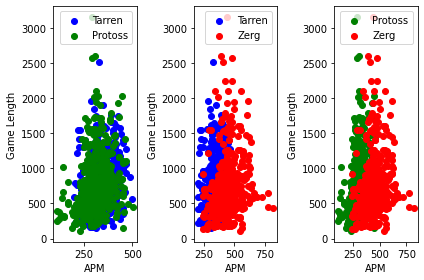

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.subplot(1, 3, 1)
# Tarren
x = np.array(Terran['apm'])
y = np.array(Terran['game_length'])
plt.scatter(x, y, color='blue')
# Protoss
x = np.array(Protoss['apm'])
y = np.array(Protoss['game_length'])
plt.scatter(x, y, color='green')
plt.legend(['Tarren', 'Protoss'])
plt.xlabel("APM")
plt.ylabel("Game Length")

plt.subplot(1, 3, 2)
# Tarren
x = np.array(Terran['apm'])
y = np.array(Terran['game_length'])
plt.scatter(x, y, color='blue')
# Zerg
x = np.array(Zerg['apm'])
y = np.array(Zerg['game_length'])
plt.scatter(x, y, color='red')
plt.legend(['Tarren', 'Zerg'])
plt.xlabel("APM")
plt.ylabel("Game Length")

plt.subplot(1, 3, 3)
# Protoss
x = np.array(Protoss['apm'])
y = np.array(Protoss['game_length'])
plt.scatter(x, y, color='green')
# Zerg
x = np.array(Zerg['apm'])
y = np.array(Zerg['game_length'])
plt.scatter(x, y, color='red')
plt.legend(['Protoss', 'Zerg'])
plt.xlabel("APM")
plt.ylabel("Game Length")

plt.tight_layout()
plt.show()

Dari ketiga scatterplot kita dapatkan kesimpulan bahwa
1. APM dari Tarren dan Protoss bisa dikatakan serupa
2. APM dari Zerg cenderung lebih tinggi ketimbang Tarren
3. APM dari Zerg cenderung lebih tinggi ketimbang Protoss

###What are the defining characteristics for each matchup (game length, resource collected, etc.)?

In [ ]:
print(df.columns)

Index(['id', 'played_at', 'tournament', 'map', 'game_length', 'winner',
       'matchup', 'p1_max_collection_rate', 'p2_max_collection_rate', 'p1_apm',
       'p2_apm', 'p1_spm', 'p2_spm', 'p1_workers_produced',
       'p2_workers_produced', 'p1_workers_killed', 'p2_workers_killed',
       'p1_workers_lost', 'p2_workers_lost', 'p1_supply_block',
       'p2_supply_block', 'p1_sq', 'p2_sq', 'p1_avg_pac_per_min',
       'p2_avg_pac_per_min', 'p1_avg_pac_action_latency',
       'p2_avg_pac_action_latency', 'p1_avg_pac_actions', 'p2_avg_pac_actions',
       'p1_avg_pac_gap', 'p2_avg_pac_gap', 'p1_avg_collection_rate_minerals',
       'p1_avg_unspent_minerals', 'p1_minerals_lost', 'p1_minerals_collected',
       'p2_avg_collection_rate_minerals', 'p2_avg_unspent_minerals',
       'p2_minerals_lost', 'p2_minerals_collected',
       'p1_avg_collection_rate_gas', 'p1_avg_unspent_gas', 'p1_gas_lost',
       'p1_gas_collected', 'p2_avg_collection_rate_gas', 'p2_avg_unspent_gas',
       'p2_gas_lo

#### Game length

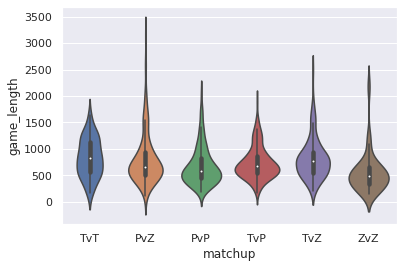

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid")

sns.violinplot( x=df["matchup"], y=df["game_length"] )
plt.show()

Melalui violin chart di atas kita dapat melihat bagaimana game_length pada setiap matchup. Berdasarkan violin chart, game_length dari setiap jenis matchup hampir sama.

#### Resource Collected

In [ ]:
rcdf = df.copy()

In [ ]:
print(df.columns)

Index(['id', 'played_at', 'tournament', 'map', 'game_length', 'winner',
       'matchup', 'p1_max_collection_rate', 'p2_max_collection_rate', 'p1_apm',
       'p2_apm', 'p1_spm', 'p2_spm', 'p1_workers_produced',
       'p2_workers_produced', 'p1_workers_killed', 'p2_workers_killed',
       'p1_workers_lost', 'p2_workers_lost', 'p1_supply_block',
       'p2_supply_block', 'p1_sq', 'p2_sq', 'p1_avg_pac_per_min',
       'p2_avg_pac_per_min', 'p1_avg_pac_action_latency',
       'p2_avg_pac_action_latency', 'p1_avg_pac_actions', 'p2_avg_pac_actions',
       'p1_avg_pac_gap', 'p2_avg_pac_gap', 'p1_avg_collection_rate_minerals',
       'p1_avg_unspent_minerals', 'p1_minerals_lost', 'p1_minerals_collected',
       'p2_avg_collection_rate_minerals', 'p2_avg_unspent_minerals',
       'p2_minerals_lost', 'p2_minerals_collected',
       'p1_avg_collection_rate_gas', 'p1_avg_unspent_gas', 'p1_gas_lost',
       'p1_gas_collected', 'p2_avg_collection_rate_gas', 'p2_avg_unspent_gas',
       'p2_gas_lo

In [ ]:
rcdf['resource_collected'] = rcdf['p1_minerals_collected'] + rcdf['p2_minerals_collected']+ rcdf['p1_gas_collected'] + rcdf['p2_gas_collected']
rcdf['resource_collected']

0      65391
1      42825
2      29479
3      97846
4      90014
       ...  
824    71473
825    26196
826    46206
827    76260
828    19729
Name: resource_collected, Length: 829, dtype: int64

In [ ]:
TvT = rcdf.loc[df['matchup'] == 'TvT']
PvP = rcdf.loc[df['matchup'] == 'PvP']
ZvZ = rcdf.loc[df['matchup'] == 'ZvZ']
TvP = rcdf.loc[df['matchup'] == 'TvP']
TvZ = rcdf.loc[df['matchup'] == 'TvZ']
PvZ = rcdf.loc[df['matchup'] == 'PvZ']

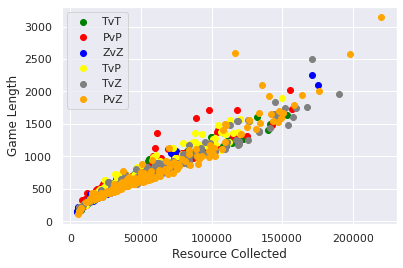

In [ ]:
# TvT Matchup
x = np.array(TvT['resource_collected'])
y = np.array(TvT['game_length'])
plt.scatter(x, y, color='green')
# PvP Matchup
x = np.array(PvP['resource_collected'])
y = np.array(PvP['game_length'])
plt.scatter(x, y, color='red')
# TvT Matchup
x = np.array(ZvZ['resource_collected'])
y = np.array(ZvZ['game_length'])
plt.scatter(x, y, color='blue')
# TvP Matchup
x = np.array(TvP['resource_collected'])
y = np.array(TvP['game_length'])
plt.scatter(x, y, color='yellow')
# TvZ Matchup
x = np.array(TvZ['resource_collected'])
y = np.array(TvZ['game_length'])
plt.scatter(x, y, color='grey')
# # PvZ Matchup
x = np.array(PvZ['resource_collected'])
y = np.array(PvZ['game_length'])
plt.scatter(x, y, color='orange')

plt.legend(['TvT', 'PvP', 'ZvZ', 'TvP', 'TvZ', 'PvZ'])
plt.xlabel("Resource Collected")
plt.ylabel("Game Length")

plt.show()

- Bisa terlihat bahwa hampir Resource Collected dari setiap matchup sama
- Terlihat juga terdapat korelasi antara Game Length dengan Resource Collected, ketika Game Length semakin besar maka Resource Collected juga semakin besar

###Is it true that a certain race is favored for certain matchups?

In [ ]:
problem3 = df[['matchup','winner','p1_race','p2_race']]
problem3

,matchup,winner,p1_race,p2_race
0,TvT,2,Terran,Terran
1,PvZ,1,Zerg,Protoss
2,PvZ,2,Zerg,Protoss
3,PvZ,2,Protoss,Zerg
4,PvZ,1,Zerg,Protoss
...,...,...,...,...
824,ZvZ,1,Zerg,Zerg
825,PvP,1,Protoss,Protoss
826,TvP,2,Terran,Protoss
827,PvZ,1,Zerg,Protoss


#### matchup TvP

In [ ]:
tvp = problem3.loc[df['matchup'] == 'TvP']
tvp

,matchup,winner,p1_race,p2_race
6,TvP,2,Protoss,Terran
11,TvP,2,Protoss,Terran
13,TvP,2,Protoss,Terran
14,TvP,1,Terran,Protoss
17,TvP,1,Protoss,Terran
...,...,...,...,...
803,TvP,1,Terran,Protoss
813,TvP,1,Protoss,Terran
820,TvP,2,Terran,Protoss
822,TvP,1,Terran,Protoss


In [ ]:
TvPTerran = 0
TvPProtoss = 0
for matchwinner, race1, race2 in zip(tvp['winner'], tvp['p1_race'], tvp['p2_race']):
  if matchwinner == 2:
    if race2 == 'Terran':
      TvPTerran += 1
    else:
      TvPProtoss += 1
  else:
    if race1 == 'Terran':
      TvPTerran += 1
    else:
      TvPProtoss += 1
print(TvPTerran)
print(TvPProtoss)

112
90


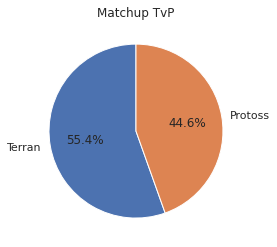

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y = np.array([TvPTerran, TvPProtoss])
mylabels = ['Terran', 'Protoss']

plt.pie(y, labels=mylabels, autopct='%1.1f%%', startangle=90)
plt.title('Matchup TvP')
plt.show()

Bisa terlihat pada piechart matchup TvP, Race Terran memiliki sedikit kecenderungan untuk menang ketimbang Race Protoss

#### matchup TvZ

In [ ]:
tvz = problem3.loc[df['matchup'] == 'TvZ']
tvz

,matchup,winner,p1_race,p2_race
7,TvZ,1,Zerg,Terran
22,TvZ,2,Terran,Zerg
23,TvZ,2,Zerg,Terran
24,TvZ,2,Terran,Zerg
25,TvZ,1,Zerg,Terran
...,...,...,...,...
810,TvZ,1,Terran,Zerg
814,TvZ,2,Terran,Zerg
817,TvZ,2,Zerg,Terran
819,TvZ,1,Zerg,Terran


In [ ]:
TvZTerran = 0
TvZZerg = 0
for matchwinner, race1, race2 in zip(tvz['winner'], tvz['p1_race'], tvz['p2_race']):
  if matchwinner == 2:
    if race2 == 'Terran':
      TvZTerran += 1
    else:
      TvZZerg += 1
  else:
    if race1 == 'Terran':
      TvZTerran += 1
    else:
      TvZZerg += 1
print(TvZTerran)
print(TvZZerg)

86
97


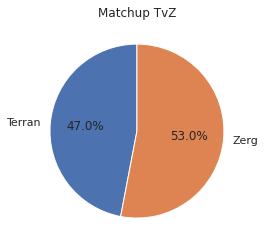

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y = np.array([TvZTerran, TvZZerg])
mylabels = ['Terran', 'Zerg']

plt.pie(y, labels=mylabels, autopct='%1.1f%%', startangle=90)
plt.title('Matchup TvZ')
plt.show()

Bisa terlihat pada piechart matchup TvZ, Race Zerg memiliki sedikit kecenderungan untuk menang ketimbang Race Terran

#### matchup PvZ

In [ ]:
pvz = problem3.loc[df['matchup'] == 'PvZ']
pvz

,matchup,winner,p1_race,p2_race
1,PvZ,1,Zerg,Protoss
2,PvZ,2,Zerg,Protoss
3,PvZ,2,Protoss,Zerg
4,PvZ,1,Zerg,Protoss
8,PvZ,2,Protoss,Zerg
...,...,...,...,...
812,PvZ,1,Zerg,Protoss
815,PvZ,2,Protoss,Zerg
816,PvZ,2,Protoss,Zerg
821,PvZ,1,Protoss,Zerg


In [ ]:
PvZProtoss = 0
PvZZerg = 0
for matchwinner, race1, race2 in zip(pvz['winner'], pvz['p1_race'], pvz['p2_race']):
  if matchwinner == 2:
    if race2 == 'Protoss':
      PvZProtoss += 1
    else:
      PvZZerg += 1
  else:
    if race1 == 'Protoss':
      PvZProtoss += 1
    else:
      PvZZerg += 1
print(PvZProtoss)
print(PvZZerg)

62
100


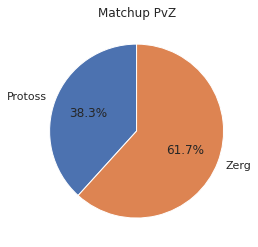

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y = np.array([PvZProtoss, PvZZerg])
mylabels = ['Protoss', 'Zerg']

plt.pie(y, labels=mylabels, autopct='%1.1f%%', startangle=90)
plt.title('Matchup PvZ')
plt.show()

Bisa terlihat pada piechart matchup TvZ, Race Zerg memiliki kecenderungan untuk menang ketimbang Race Protoss

###Does the map choice affect a matchup?

### Other Analysis

## Pencarian Machine Learning Model

In [ ]:
newdf.head()

game_length  winner  max_collection_rate  apm   spm  workers_produced  \
0          848       0                 3778  316  26.3                75   
1          612       1                 4344  398  42.9                97   
2          486       0                 3095  389  35.9                80   
3         1078       0                 4064  449  40.2                77   
4         1001       1                 4484  627  37.6                98   

   workers_killed  workers_lost  supply_block   sq  ...  avg_pac_actions  \
0              18            17            75  134  ...             8.11   
1              22            21            30  126  ...             6.65   
2              11            17            20  118  ...             9.47   
3              68            30            15  138  ...             9.02   
4              24            25            25  169  ...            11.50   

   avg_pac_gap  avg_collection_rate_minerals  avg_unspent_minerals  \
0         0.06                        1808.2                 241.2   
1         0.06                        1938.9                 473.6   
2         0.06                        1563.7                 232.1   
3         0.06                        2107.6                 535.6   
4         0.04                        2306.8                 259.8   

   minerals_lost  minerals_collected  avg_collection_rate_gas  \
0          10341               25162                    533.8   
1           3075               20305                    473.9   
2           4200               13525                    226.5   
3          13650               37470                    749.7   
4          21675               37048                    826.1   

   avg_unspent_gas  gas_lost  gas_collected  
0            273.8      3436           6384  
1            236.7       625           4265  
2            157.6       800           1668  
3            401.2      5850          11682  
4            299.8      8975          11930  

[5 rows x 22 columns]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Melakukan scaling data
scaler=StandardScaler()
newdf=pd.DataFrame(scaler.fit_transform(newdf), columns=newdf.columns)

newdf
# Melakukan splitting menjadi train dan validation
X_train, X_valid, y_train, y_valid = train_test_split(newdf, target,
                                                    test_size=0.2, random_state=1)
X_train, X_valid, ohe_train, ohe_valid = train_test_split(newdf, ohetarget,
                                                    test_size=0.2, random_state=1)

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)

(1326, 22) (1326,)
(332, 22) (332,)


In [ ]:
# Training menggunakan Random Forest Classifier model
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
pred = rfc.predict(X_valid)
print(accuracy_score(y_valid, pred))

0.8493975903614458


In [ ]:
print(rfc.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'auto', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [ ]:
# Training menggunakan Support Vector Classification model

from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)
pred2 = svc.predict(X_valid)
print(accuracy_score(y_valid, pred2))

0.8554216867469879


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)
pred3 = xgb.predict(X_valid)
print(accuracy_score(y_valid, pred3))

0.8463855421686747


In [ ]:
# Mengisntall modul catboost
!pip install catboost > /dev/null

In [ ]:
# Melatih dan mengevaluasi model catboost regressor

from catboost import CatBoostClassifier

cb = CatBoostClassifier(silent=True)
cb.fit(X_train, y_train)
pred4 = cb.predict(X_valid)
print(accuracy_score(y_valid, pred4))

0.9006024096385542


In [ ]:
# Training menggunakan Random Forest Classifier model
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error

bc = GradientBoostingClassifier()
bc.fit(X_train, y_train)
pred = bc.predict(X_valid)
print(accuracy_score(y_valid, pred))

0.8524096385542169


In [ ]:
# Training menggunakan Random Forest Classifier model
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import mean_squared_error

bc = HistGradientBoostingClassifier()
bc.fit(X_train, y_train)
pred = bc.predict(X_valid)
print(accuracy_score(y_valid, pred))

0.8825301204819277


## Deep Neural Network

In [ ]:
# Menggunakan fungsi Callback

from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import TensorBoard

# Fungsi callback untuk memplotting loss
tensor_board = TensorBoard(log_dir='./Graph', histogram_freq=1,
                            write_graph=True, write_images=True)

# Fungsi callback untuk mereduksi learning rate bila tidak mengalami penurunan loss
reduce_lr = ReduceLROnPlateau(
    monitor = 'loss',
    factor = 0.4,
    patience = 5,
    verbose = 1)

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dropout, BatchNormalization
from keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, Adadelta, RMSprop

model2 = Sequential()
model2.add(Dense(256, input_shape = (22,), activation = "selu"))

model2.add(Dropout(0.1))
model2.add(BatchNormalization())
model2.add(Dense(256, activation = "selu"))

model2.add(Dropout(0.1))
model2.add(BatchNormalization())
model2.add(Dense(128, activation = "selu"))

model2.add(Dropout(0.05))
model2.add(Dense(3, activation = "softmax"))
model2.compile(SGD(lr = 0.01), "categorical_crossentropy", metrics = ["accuracy"])

model2.summary()

model2.fit(X_train, ohe_train, verbose=1, epochs=150, validation_split = 0.2, callbacks = [reduce_lr,tensor_board])
deep1 = model2.predict(X_valid)
deep1 = np.argmax(deep1, axis=1)
print(accuracy_score(y_valid, deep1))

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               5888      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 batch_normalization_1 (Batc  (None, 256)              1024      
 hNormalization)                                        

Epoch 1/150
34/34 [==============================] - 5s 66ms/step - loss: 0.9796 - accuracy: 0.6028 - val_loss: 0.7318 - val_accuracy: 0.6278 - lr: 0.0100
Epoch 2/150
34/34 [==============================] - 1s 21ms/step - loss: 0.7401 - accuracy: 0.6877 - val_loss: 0.6961 - val_accuracy: 0.6842 - lr: 0.0100
Epoch 3/150
34/34 [==============================] - 1s 24ms/step - loss: 0.6600 - accuracy: 0.7255 - val_loss: 0.6221 - val_accuracy: 0.7143 - lr: 0.0100
Epoch 4/150
34/34 [==============================] - 1s 26ms/step - loss: 0.6232 - accuracy: 0.7208 - val_loss: 0.6793 - val_accuracy: 0.6880 - lr: 0.0100
Epoch 5/150
34/34 [==============================] - 1s 32ms/step - loss: 0.6176 - accuracy: 0.7491 - val_loss: 0.5986 - val_accuracy: 0.7293 - lr: 0.0100
Epoch 6/150
34/34 [==============================] - 1s 26ms/step - loss: 0.5855 - accuracy: 0.7462 - val_loss: 0.5952 - val_accuracy: 0.7218 - lr: 0.0100
Epoch 7/150
34/34 [==============================] - 1s 33ms/step - lo

In [ ]:
print(deep1)

[0 1 2 1 0 1 1 2 1 2 0 1 2 1 0 2 1 0 2 0 0 0 1 2 1 2 1 2 0 2 0 1 2 1 0 1 1
 0 2 1 1 2 0 1 1 1 2 0 2 1 0 2 1 2 0 0 1 1 2 1 1 2 2 0 0 2 1 1 1 1 2 0 0 2
 0 1 2 2 2 1 0 1 0 0 0 0 0 0 2 2 2 0 1 2 0 1 0 2 0 0 2 0 0 1 2 2 0 2 1 0 0
 2 0 0 0 0 2 2 0 0 0 0 2 1 2 0 1 0 1 0 1 1 1 0 1 1 1 2 1 2 0 0 0 1 1 1 2 0
 0 0 0 1 2 0 2 2 2 2 2 0 2 2 2 0 1 0 0 2 0 1 0 0 2 2 0 2 2 1 0 0 2 2 0 2 1
 0 1 0 2 0 0 0 2 1 0 1 2 1 1 0 0 0 2 1 1 0 2 0 2 0 1 0 2 0 0 0 1 1 1 0 1 2
 0 2 1 0 2 0 0 1 2 1 2 0 0 1 0 1 2 1 0 0 1 2 0 0 0 2 2 1 1 0 2 1 1 2 0 1 0
 0 2 0 0 2 2 0 1 0 1 0 1 0 2 1 2 0 2 0 0 1 1 2 2 0 0 1 1 0 0 1 2 0 1 2 0 2
 2 1 2 1 0 1 2 1 2 0 0 0 2 0 0 0 1 1 2 1 0 0 0 2 1 2 2 1 1 0 0 0 0 2 0 1]


In [ ]:
# Memplotting accuracy

%load_ext tensorboard
%tensorboard --logdir /content/Graph
from tensorboard import notebook
notebook.list()

<IPython.core.display.Javascript object>

Known TensorBoard instances:
  - port 6006: logdir /content/Graph (started 0:00:00 ago; pid 944)


## Hyperparameter Tuning

In [ ]:
# Membuat self defined accuracy metric

from sklearn.metrics import make_scorer

def func(y_true, y_predicted):
    accuracy = accuracy_score(y_true, ypredicted)
    return accyracy

accuracy = make_scorer(func, greater_is_better=True)

In [ ]:
# Mencari hyperparameter terbaik untuk Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import RandomizedSearchCV

# Menggunakan cross validation untuk mencari parameter
model = RandomForestClassifier()
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=1)
space = {'max_features': ['auto', 'sqrt'],
         'max_depth': [2,4],
         'min_samples_split': [2],
         'min_samples_leaf': [1],
         'bootstrap': [True, False]}

search = RandomizedSearchCV(model, space, n_iter=50,
                            scoring=accuracy,
                            n_jobs=-1, cv=cv,
                            random_state=1,
                            verbose=2)

result = search.fit(X_train, y_train)
print(result.best_score_)
print(result.best_params_)
result.best_estimator_

Fitting 15 folds for each of 8 candidates, totalling 120 fits


KeyboardInterrupt: ignored

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)

# fitting the model for grid search
grid.fit(X_train, y_train)
print(grid.best_score_)
print(grid.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.391 total time=   0.3s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.389 total time=   0.4s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.389 total time=   0.3s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.389 total time=   0.4s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.389 total time=   0.3s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.733 total time=   0.2s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.725 total time=   0.3s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.725 total time=   0.3s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.709 total time=   0.3s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.717 total time=   0.2s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.699 total time=   0.3s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

In [ ]:
# Mencari hyperparameter terbaik untuk XGBoost

import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

xgb = XGBClassifier()

paramgrid = {'colsample_bytree': [0.75],
             'gamma': [0.1, 0.05],
             'learning_rate': [0.1, 0.05],
             'min_child_weight': [0.01],
             'n_estimators': [500],
             'reg_alpha': [1],
             'reg_lambda': [2],
             'sampling_method': ['uniform'],
             'subsample': [0.55]}

gridxgb = GridSearchCV(xgb, paramgrid,
                    scoring=accuracy,
                    cv=cv, n_jobs=-1,
                    verbose=2)

gridxgb.fit(X_train, y_train)
print(gridxgb.best_params_)
pred = gridxgb.predict(X_valid)
print(accuracy_score(y_valid, pred))

## Hasil Prediksi Test Data

Parameter yang digunakan sudah melalui tuning manual:)

In [ ]:
# Melatih dan mengevaluasi model support vector regressor

from sklearn.svm import SVC
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import GridSearchCV

svc = SVC(C = 100, gamma = 0.008, kernel = 'rbf')
svc.fit(X_train, y_train)
pred1 = svc.predict(X_valid)
print(accuracy_score(y_valid, pred1))

0.9066265060240963


In [ ]:
# Mencari hyperparameter terbaik untuk XGBoost
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(colsample_bytree = 0.75,
                    gamma = 0.1,
                    learning_rate = 0.1,
                    min_child_weight = 0.015,
                    n_estimators = 500,
                    reg_alpha = 1,
                    reg_lambda = 2,
                    sampling_method = 'uniform',
                    subsample = 0.55)
xgb = xgb.fit(X_train,y_train)
pred2 = xgb.predict(X_valid)
print(accuracy_score(y_valid, pred2))

0.9126506024096386


In [ ]:
# Melatih dan mengevaluasi model catboost regressor

from catboost import CatBoostClassifier

cb = CatBoostClassifier(
    iterations = 1000, # 1000 are ideal
    loss_function='MultiClass',
    eval_metric = 'MultiClass',
    leaf_estimation_iterations = 100,
    random_strength = 0.5,
    depth = 6,
    l2_leaf_reg = 5,
    learning_rate=0.05,
    bagging_temperature = 0.8,
)
cb.fit(X_train, y_train)
pred3 = cb.predict(X_valid)
print(accuracy_score(y_valid, pred3))

0:	learn: 1.0452076	total: 50.7ms	remaining: 50.7s
1:	learn: 1.0037755	total: 96.1ms	remaining: 48s
2:	learn: 0.9675784	total: 143ms	remaining: 47.5s
3:	learn: 0.9276103	total: 189ms	remaining: 47.1s
4:	learn: 0.8979113	total: 235ms	remaining: 46.8s
5:	learn: 0.8650746	total: 284ms	remaining: 47s
6:	learn: 0.8398574	total: 336ms	remaining: 47.7s
7:	learn: 0.8121134	total: 391ms	remaining: 48.5s
8:	learn: 0.7827142	total: 439ms	remaining: 48.3s
9:	learn: 0.7559351	total: 489ms	remaining: 48.4s
10:	learn: 0.7383606	total: 536ms	remaining: 48.2s
11:	learn: 0.7213340	total: 583ms	remaining: 48s
12:	learn: 0.7036403	total: 628ms	remaining: 47.7s
13:	learn: 0.6894929	total: 676ms	remaining: 47.6s
14:	learn: 0.6763641	total: 800ms	remaining: 52.5s
15:	learn: 0.6650024	total: 875ms	remaining: 53.8s
16:	learn: 0.6546509	total: 924ms	remaining: 53.4s
17:	learn: 0.6418094	total: 971ms	remaining: 53s
18:	learn: 0.6296114	total: 1.02s	remaining: 52.7s
19:	learn: 0.6201925	total: 1.06s	remaining: 52

[[ 85  10]
 [  8 119]]


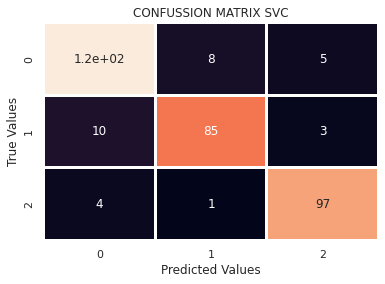

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_valid,pred1,labels=[1,0]))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_valid,pred1),annot=True,lw =2,cbar=False)
plt.ylabel("True Values")
plt.xlabel("Predicted Values")
plt.title("CONFUSSION MATRIX SVC")
plt.show()

[[ 86  10]
 [  7 122]]


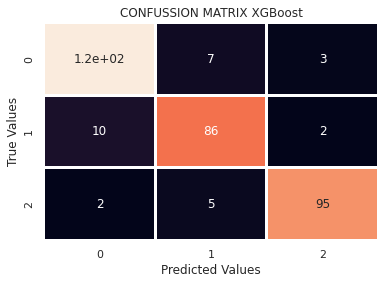

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_valid,pred2,labels=[1,0]))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_valid,pred2),annot=True,lw =2,cbar=False)
plt.ylabel("True Values")
plt.xlabel("Predicted Values")
plt.title("CONFUSSION MATRIX XGBoost")
plt.show()

[[ 86  10]
 [  7 120]]


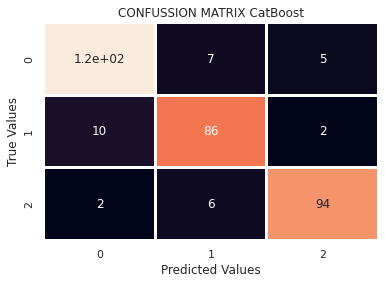

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_valid,pred3,labels=[1,0]))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_valid,pred3),annot=True,lw =2,cbar=False)
plt.ylabel("True Values")
plt.xlabel("Predicted Values")
plt.title("CONFUSSION MATRIX CatBoost")
plt.show()

## Training Model 100%

In [ ]:
# Melatih dan mengevaluasi model support vector regressor

from sklearn.svm import SVC
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import GridSearchCV

svc = SVC(C = 100, gamma = 0.008, kernel = 'rbf')
svc.fit(newdf, target)

SVC(C=100, gamma=0.008)

In [ ]:
# Mencari hyperparameter terbaik untuk XGBoost
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(colsample_bytree = 0.75,
                    gamma = 0.1,
                    learning_rate = 0.1,
                    min_child_weight = 0.015,
                    n_estimators = 500,
                    reg_alpha = 1,
                    reg_lambda = 2,
                    sampling_method = 'uniform',
                    subsample = 0.55)
xgb = xgb.fit(newdf,target)

In [ ]:
# Melatih dan mengevaluasi model CatBoost Classifier

from catboost import CatBoostClassifier

cb = CatBoostClassifier(
    iterations = 1000, # 1000 are ideal
    loss_function='MultiClass',
    eval_metric = 'MultiClass',
    leaf_estimation_iterations = 100,
    random_strength = 0.5,
    depth = 6,
    l2_leaf_reg = 5,
    learning_rate=0.05,
    bagging_temperature = 0.8,
)
cb.fit(newdf, target)

0:	learn: 1.0422881	total: 76.6ms	remaining: 1m 16s
1:	learn: 0.9996575	total: 139ms	remaining: 1m 9s
2:	learn: 0.9514666	total: 228ms	remaining: 1m 15s
3:	learn: 0.9185301	total: 373ms	remaining: 1m 32s
4:	learn: 0.8885615	total: 498ms	remaining: 1m 39s
5:	learn: 0.8546738	total: 580ms	remaining: 1m 36s
6:	learn: 0.8249850	total: 642ms	remaining: 1m 31s
7:	learn: 0.8030100	total: 804ms	remaining: 1m 39s
8:	learn: 0.7789828	total: 935ms	remaining: 1m 42s
9:	learn: 0.7604243	total: 992ms	remaining: 1m 38s
10:	learn: 0.7383909	total: 1.05s	remaining: 1m 34s
11:	learn: 0.7221850	total: 1.12s	remaining: 1m 31s
12:	learn: 0.7020050	total: 1.19s	remaining: 1m 30s
13:	learn: 0.6817552	total: 1.31s	remaining: 1m 32s
14:	learn: 0.6664107	total: 1.45s	remaining: 1m 35s
15:	learn: 0.6537737	total: 1.58s	remaining: 1m 37s
16:	learn: 0.6409314	total: 1.68s	remaining: 1m 36s
17:	learn: 0.6294457	total: 1.74s	remaining: 1m 34s
18:	learn: 0.6192254	total: 1.83s	remaining: 1m 34s
19:	learn: 0.6071637	t

## Model Deployment

In [ ]:
test = pd.read_csv('/content/test.csv')

In [ ]:
test.drop(['played_at', 'tournament', 'id', 'map'], axis=1, inplace=True)

In [ ]:
# Membuat dataframe baru untuk player 1
testp1 = test.copy()
# Menghilangkan data player 2
for name in testp1.columns:
  if name[0:2] == 'p2':
    testp1.drop([name], axis=1, inplace=True)
# Mendapatkan status kemenangan player 1
new_winner = []
for win in testp1['winner']:
  if win == 2:
    new_winner.append(0)
  else:
    new_winner.append(1)
testp1['winner'] = new_winner
# Menyamakan column name dengan dataframe player 2
testp1.columns = testp1.columns.str.replace("p1_", "")

In [ ]:
# Membuat dataframe baru untuk player 2
testp2 = test.copy()
# Menghilangkan data player 1
for name in testp2.columns:
  if name[0:2] == 'p1':
    testp2.drop([name], axis=1, inplace=True)
# Mendapatkan status kemenangan player 2
new_winner = []
for win in testp2['winner']:
  if win == 2:
    new_winner.append(1)
  else:
    new_winner.append(0)
testp2['winner'] = new_winner
# Menyamakan column name dengan dataframe player 1
testp2.columns = testp2.columns.str.replace("p2_", "")

In [ ]:
testp1=pd.DataFrame(scaler.fit_transform(testp1), columns=testp1.columns)
testp2=pd.DataFrame(scaler.fit_transform(testp2), columns=testp2.columns)

In [ ]:
hasilp1a = svc.predict(testp1)
hasilp1b = xgb.predict(testp1)
hasilp1c = cb.predict(testp1)
hasilp1c = hasilp1c.flatten()

hasilp2a = svc.predict(testp2)
hasilp2b = xgb.predict(testp2)
hasilp2c = cb.predict(testp2)
hasilp2c = hasilp2c.flatten()

print(hasilp1a)
print(hasilp2b)

[1 1 0 0 2 1 1 0 2 0 2 2 1 1 0 1 0 0 0 0 1 0 2 0 2 0 1 1 1 0 1 0 2 2 1 2 2
 0 0 1 1 1 0 1 1 1 1 0 0 1 2 0 1 1 1 1 0 2 2 0 2 0 0 1 0 0 2 0 2 2 0 0 0 1
 0 1 2 1 1 1 2 1 0 2 1 2 1 0 0 1 0 2 0 0 1 0 0 2 1 1 2 0 2 1 0 2 1 2 0 1 0
 1 0 1 2 1 2 0 2 2 0 1 0 2 2 2 0 0 0 1 2 0 0 2 2 1 1 2 1 0 1 1 0 2 0 1 1 2
 2 0 0 0 0 0 1 0 1 1 2 2 1 1 0 1 1 2 1 0 1 2 1 0 1 0 1 0 1 2 2 0 1 1 0 1 2
 0 1 2 1 2 0 2 1 2 0 2 2 0 2 2 0 2 0 2 1 2 0 1 1 0 0 1 1 1 1 0 2 1 2 0 1 1
 2 0 1 1 0 0 2 1 2 2 1 2 0 2 1 2 0 0 0 0 2 2 0 0 0 2 0 0 0 1 1 0 1 1 0 2 2
 2 2 2 2 1 2 0 0 1 0 1 2 1 1 0 2 1 2 0 0 0 2 0 0 0 0 0 0 0 0 1 0 2 2 0 2 0
 1 2 0 1 0 1 2 1 0 2 1 2 2 2 1 1 0 0 1 1 2 1 1 2 1 0 2 0 1 2 1 2 2 0 0 0 0
 1 1 0 2 2 0 0 1 1 1 0 0 1 0 0 0 1 0 2 2 0 0 0 2 0 1 2 2 0 0 2 2 0 1 2 2 2
 1 0 2 0 0 0 2 1 1 2 2 0 1 0 0 1 0 0 0 0 0 2 2 2 0 0 1 0 0 2 0 1 2 0 2 0 1
 0 2 1 1 2 1 2 1 1 1 0 1 2 2 1 1 1 0 0 2 0 1 1 2 0 2 0 0 2 0 0 0 2 2 1 1 0
 1 1 0 2 0 1 0 1 1 2 2 1 1 0 1 0 2 0 0 1 0 0 2 1 0 0 1 0 1 2 2 1 0 2 0 0 0
 1 1 1 2 0 1 0 1 2 2 2 2 

In [ ]:
hasilp1a = le.inverse_transform(hasilp1a)
hasilp1b = le.inverse_transform(hasilp1b)
hasilp1c = le.inverse_transform(hasilp1c)

hasilp2a = le.inverse_transform(hasilp2a)
hasilp2b = le.inverse_transform(hasilp2b)
hasilp2c = le.inverse_transform(hasilp2c)

In [ ]:
campur = []

for a,b,c in zip(hasilp1a, hasilp1b, hasilp1c):
  if a==b:
    campur.append(a)
  elif a==c:
    campur.append(a)
  elif b==c:
    campur.append(b)
  else:
    campur.append(b)

In [ ]:
campur2 = []

for a,b,c in zip(hasilp2a, hasilp2b, hasilp2c):
  if a==b:
    campur2.append(a)
  elif a==c:
    campur2.append(a)
  elif b==c:
    campur2.append(b)
  else:
    campur2.append(b)

In [ ]:
final = []
for race1,race2 in zip(campur,campur2):
  temp = []
  temp.append(race1)
  temp.append(race2)
  if sorted(temp) == ['Terran','Zerg']:
    final.append('TvZ')
  elif sorted(temp) == ['Protoss','Terran']:
    final.append('TvP')
  elif sorted(temp) == ['Protoss', 'Zerg']:
    final.append('PvZ')
  elif set(temp) == {'Protoss'}:
    final.append('PvP')
  elif set(temp) == {'Terran'}:
    final.append('TvT')
  elif set(temp) == {'Zerg'}:
    final.append('ZvZ')
  else:
    print(set(temp))
    print('aneh')

In [ ]:
print(final)

['TvP', 'TvP', 'TvP', 'PvZ', 'TvZ', 'TvZ', 'TvP', 'TvP', 'PvZ', 'PvP', 'PvZ', 'PvZ', 'TvP', 'TvZ', 'TvP', 'TvT', 'PvP', 'TvP', 'PvZ', 'PvP', 'TvP', 'PvP', 'PvZ', 'TvP', 'ZvZ', 'PvP', 'PvP', 'TvP', 'TvP', 'PvP', 'TvZ', 'PvP', 'PvZ', 'TvZ', 'TvT', 'TvZ', 'PvZ', 'TvP', 'PvP', 'TvT', 'TvZ', 'TvP', 'PvP', 'TvP', 'TvT', 'TvP', 'TvT', 'TvZ', 'PvP', 'TvT', 'TvZ', 'PvP', 'TvZ', 'TvP', 'TvZ', 'TvP', 'TvT', 'TvZ', 'ZvZ', 'PvP', 'PvZ', 'TvP', 'PvZ', 'TvZ', 'TvP', 'TvP', 'PvZ', 'PvZ', 'TvZ', 'TvZ', 'TvP', 'PvP', 'PvZ', 'TvZ', 'PvP', 'TvT', 'TvZ', 'TvP', 'TvT', 'TvZ', 'ZvZ', 'TvP', 'TvP', 'PvZ', 'TvZ', 'ZvZ', 'TvP', 'PvZ', 'TvP', 'TvZ', 'PvZ', 'TvZ', 'TvZ', 'TvP', 'PvZ', 'TvP', 'PvZ', 'TvZ', 'TvP', 'TvT', 'PvZ', 'PvZ', 'PvZ', 'TvZ', 'PvZ', 'PvZ', 'TvP', 'TvZ', 'PvZ', 'TvT', 'PvP', 'TvT', 'PvP', 'TvP', 'TvZ', 'PvP', 'ZvZ', 'PvP', 'ZvZ', 'TvZ', 'TvP', 'TvT', 'TvP', 'ZvZ', 'PvZ', 'PvZ', 'TvP', 'PvP', 'PvP', 'TvT', 'PvZ', 'TvP', 'TvP', 'PvZ', 'ZvZ', 'TvZ', 'TvT', 'PvZ', 'TvP', 'PvP', 'ZvZ', 'TvT', 'PvP'

In [ ]:
submission = pd.read_csv('/content/submission.csv')
submission

,id,matchup
0,486d95087ff4445da692067dfdbd3870,ZvZ
1,2de9f70785c848f8bb580f188c4f0302,ZvZ
2,38ca5b10579f4dc9b7d5b54c5271afab,ZvZ
3,bf780984dd2f403ba3668a2997b89841,ZvZ
4,8c59ca38e232444bb30648cc9f2d221e,ZvZ
...,...,...
549,4969f529046c418ab915071957a94693,ZvZ
550,2fca4fed571e4d15ae0bf1b321702edf,ZvZ
551,27b0d332225b4c74937f8dc5f6aabbff,ZvZ
552,aae99b57bebe4c6c9ce9dadb63c3515f,ZvZ


In [ ]:
submission['matchup'] = final
submission

,id,matchup
0,486d95087ff4445da692067dfdbd3870,TvP
1,2de9f70785c848f8bb580f188c4f0302,TvP
2,38ca5b10579f4dc9b7d5b54c5271afab,TvP
3,bf780984dd2f403ba3668a2997b89841,PvZ
4,8c59ca38e232444bb30648cc9f2d221e,TvZ
...,...,...
549,4969f529046c418ab915071957a94693,TvP
550,2fca4fed571e4d15ae0bf1b321702edf,PvP
551,27b0d332225b4c74937f8dc5f6aabbff,TvP
552,aae99b57bebe4c6c9ce9dadb63c3515f,ZvZ


In [ ]:
submission.to_csv('seventhtry.csv', index=False)